In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.feature_selection import mutual_info_classif, SelectKBest, SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

import statsmodels.api as sm

reglog = LogisticRegression()

df = pd.read_csv('Dados completos.csv',sep=';')
df = df.drop(columns=['Unnamed: 7','Unnamed: 8'])

colunas_texto = df.select_dtypes(include=['object', 'string']).columns

for coluna in colunas_texto:
    df[coluna] = df[coluna].str.replace('.', '', regex=False).astype(float)

Random Forest puro (validation set) -   MÉTODO EMBUTIDO

Acurácia: 0.88


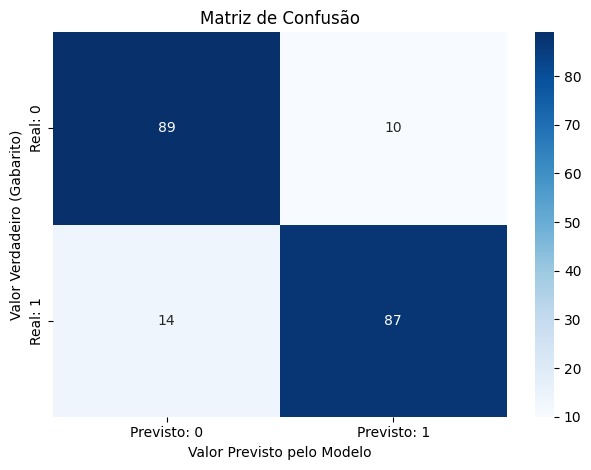

Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        99
           1       0.90      0.86      0.88       101

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.88      0.88      0.88       200



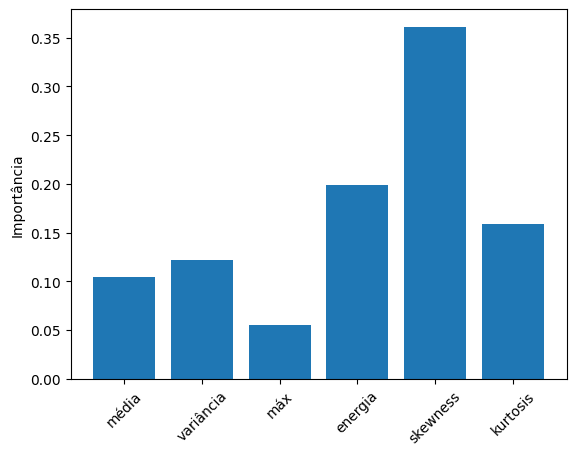

In [94]:
X = df.drop(columns='Label')
Y = df['Label']

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=0,stratify=Y)

modelo = RandomForestClassifier(n_estimators=100,max_depth=None,random_state=0)

modelo.fit(X_train,Y_train)

Y_predict = modelo.predict(X_test)

print('Acurácia:',accuracy_score(Y_test,Y_predict))

matriz_c = confusion_matrix(Y_test,Y_predict)

sns.heatmap(matriz_c, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto: 0', 'Previsto: 1'], 
            yticklabels=['Real: 0', 'Real: 1'])

plt.title('Matriz de Confusão')
plt.ylabel('Valor Verdadeiro (Gabarito)')
plt.xlabel('Valor Previsto pelo Modelo')
plt.tight_layout()
plt.show()

print('Report:')
print(classification_report(Y_test,Y_predict))

nomes = ['média','variância','máx','energia','skewness','kurtosis']

imp = modelo.feature_importances_

plt.bar(nomes,imp)
plt.ylabel("Importância")
plt.xticks(rotation=45)
plt.show()


K-Fold sem seleção

In [95]:
modelo = RandomForestClassifier(n_estimators=100,criterion='entropy',max_depth=None,random_state=0)
cv = KFold(n_splits=10,shuffle=True,random_state=0)

X = df.drop(columns='Label')
Y = df['Label']

scores = cross_validate(modelo,X,Y,cv=cv,scoring='accuracy')

#print(scores)
acc = scores['test_score'].mean()
sd = scores['test_score'].std()
print(f'Acuracia média: {acc:.2f} +/- {sd:.2f}')

Acuracia média: 0.90 +/- 0.04


Seleção de atributos - Informação mútua

[0.14236437 0.2987571  0.         0.2700528  0.35952615 0.20844035]
Index(['Variância', 'Energia', 'Skewness'], dtype='object')


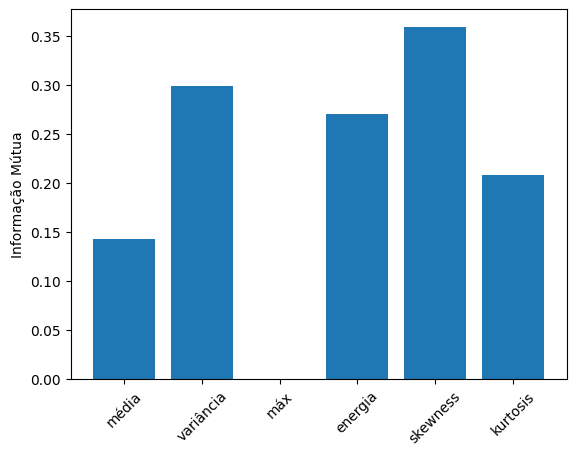

In [96]:
X = df.drop(columns='Label')
Y = df['Label']

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=0,stratify=Y)

modelo = RandomForestClassifier(n_estimators=100,max_depth=None,random_state=0)

seletor = SelectKBest(mutual_info_classif,k=3)

X_mi = seletor.fit_transform(X_train,Y_train)

print(seletor.scores_)
#print(seletor.get_support())

colunas_selecionadas = X_train.columns[seletor.get_support()]
print(colunas_selecionadas)

nomes = ['média','variância','máx','energia','skewness','kurtosis']

plt.bar(nomes,seletor.scores_)
plt.ylabel("Informação Mútua")
plt.xticks(rotation=45)
plt.show()

Fazendo Random Forest puro com os atributos selecionados

Acurácia: 0.865
Acurácia: 0.865


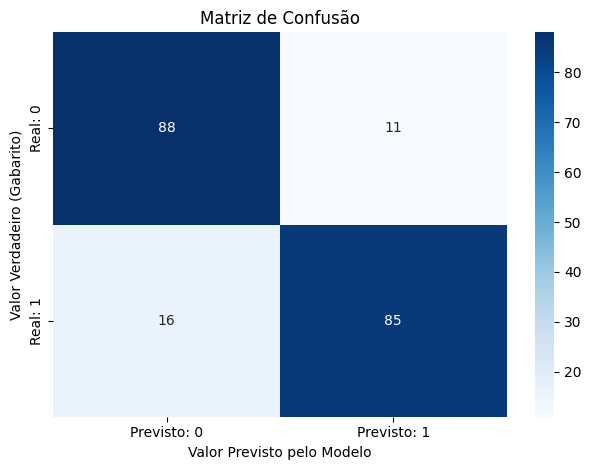

Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87        99
           1       0.89      0.84      0.86       101

    accuracy                           0.86       200
   macro avg       0.87      0.87      0.86       200
weighted avg       0.87      0.86      0.86       200



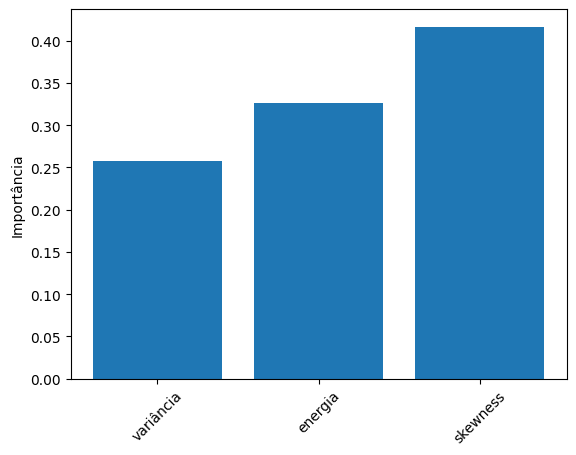

In [97]:
#X = df.drop(columns='Label')
X = df[['Variância','Energia','Skewness']]
Y = df['Label']

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=0,stratify=Y)

modelo = RandomForestClassifier(n_estimators=100,max_depth=None,random_state=0)

modelo.fit(X_train,Y_train)

Y_predict = modelo.predict(X_test)

print('Acurácia:',accuracy_score(Y_test,Y_predict))

print('Acurácia:',accuracy_score(Y_test,Y_predict))

matriz_c = confusion_matrix(Y_test,Y_predict)

sns.heatmap(matriz_c, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto: 0', 'Previsto: 1'], 
            yticklabels=['Real: 0', 'Real: 1'])

plt.title('Matriz de Confusão')
plt.ylabel('Valor Verdadeiro (Gabarito)')
plt.xlabel('Valor Previsto pelo Modelo')
plt.tight_layout()
plt.show()

print('Report:')
print(classification_report(Y_test,Y_predict))

nomes = ['variância','energia','skewness']

imp = modelo.feature_importances_

plt.bar(nomes,imp)
plt.ylabel("Importância")
plt.xticks(rotation=45)
plt.show()


Fazendo uma pipeline: Primeiro o dataset original é divivido em 10 folds. Dentro de cada fold é realizado uma seleção de atributos e então o modelo é treinado.

In [98]:
X = df.drop(columns='Label')
Y = df['Label']

pipe = Pipeline([('seleção',SelectKBest(mutual_info_classif,k=3)),
                  ('modelo',RandomForestClassifier(n_estimators=100,max_depth=None,criterion='entropy',random_state=0))])

cv = KFold(n_splits=10,shuffle=True,random_state=0)

scores = cross_validate(pipe,X,Y,cv=cv,scoring=['f1','accuracy'])

print('Acurácia:',scores['test_accuracy'].mean())


Acurácia: 0.866


Forward Selection

In [100]:

sfs_forward = SequentialFeatureSelector(
    estimator=reglog,
    n_features_to_select=4,
    tol=0.01,
    direction='forward', 
    cv=5)
X_forward = sfs_forward.fit_transform(X_train, Y_train)
print("Forward:", sfs_forward.get_support(indices=False))

display(X_train.head(0))

Forward: [ True False False  True  True  True False]


,const,Média,Variância,Máximo,Energia,Skewness,Kurtosis


Random Forest: Skewness, Energia e Kurtosis

Informação Mútua: Skewness, Energia e Variância

Forward Selection: Skewness, Energia e Máximo

Usando Reg Log

0.64


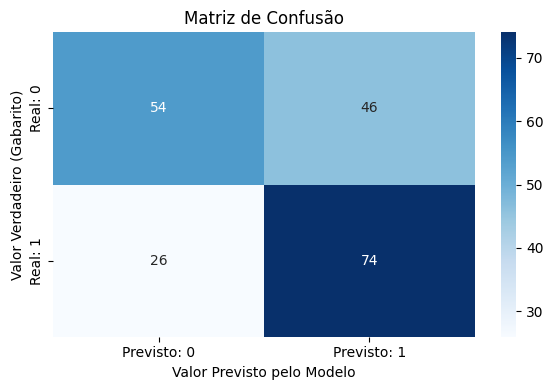

Optimization terminated successfully.
         Current function value: 0.530505
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  Label   No. Observations:                  800
Model:                          Logit   Df Residuals:                      793
Method:                           MLE   Df Model:                            6
Date:                Wed, 23 Sep 2026   Pseudo R-squ.:                  0.2346
Time:                        21:36:06   Log-Likelihood:                -424.40
converged:                       True   LL-Null:                       -554.50
Covariance Type:            nonrobust   LLR p-value:                 2.730e-53
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5257      0.200      2.634      0.008       0.135       0.917
Média      -1.956e-17    1.1e

In [99]:
X = df.drop(columns='Label')
Y = df['Label']

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

reglog.fit(X_train,Y_train)

Y_predict = reglog.predict(X_test)

print(accuracy_score(Y_test,Y_predict))

matriz_c = confusion_matrix(Y_test,Y_predict)

plt.figure(figsize=(6, 4))
sns.heatmap(matriz_c, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto: 0', 'Previsto: 1'], 
            yticklabels=['Real: 0', 'Real: 1'])

plt.title('Matriz de Confusão')
plt.ylabel('Valor Verdadeiro (Gabarito)')
plt.xlabel('Valor Previsto pelo Modelo')
plt.tight_layout()
plt.show()

X_train = sm.add_constant(X_train)

modelo_sm = sm.Logit(Y_train, X_train).fit()

print(modelo_sm.summary())

0.68


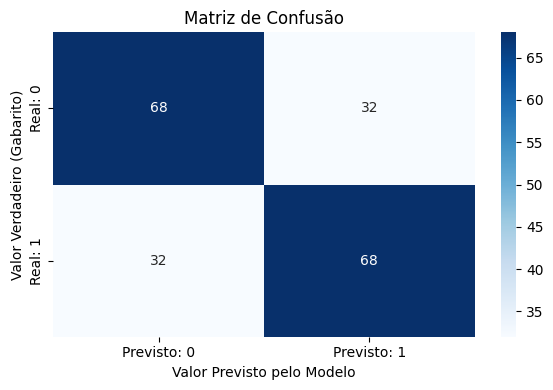

Optimization terminated successfully.
         Current function value: 0.533359
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  Label   No. Observations:                  800
Model:                          Logit   Df Residuals:                      797
Method:                           MLE   Df Model:                            2
Date:                Wed, 23 Sep 2026   Pseudo R-squ.:                  0.2305
Time:                        21:38:39   Log-Likelihood:                -426.69
converged:                       True   LL-Null:                       -554.50
Covariance Type:            nonrobust   LLR p-value:                 3.116e-56
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7287      0.135      5.413      0.000       0.465       0.992
Skewness    1.536e-16   1.28e

In [108]:
X = df[['Skewness','Energia']]
Y = df['Label']

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

reglog.fit(X_train,Y_train)

Y_predict = reglog.predict(X_test)

print(accuracy_score(Y_test,Y_predict))

matriz_c = confusion_matrix(Y_test,Y_predict)

plt.figure(figsize=(6, 4))
sns.heatmap(matriz_c, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto: 0', 'Previsto: 1'], 
            yticklabels=['Real: 0', 'Real: 1'])

plt.title('Matriz de Confusão')
plt.ylabel('Valor Verdadeiro (Gabarito)')
plt.xlabel('Valor Previsto pelo Modelo')
plt.tight_layout()
plt.show()

X_train = sm.add_constant(X_train)

modelo_sm = sm.Logit(Y_train, X_train).fit()

print(modelo_sm.summary())